In [1]:
# import os
# 
# os.mkdir('./embeddings')
# os.mkdir('./cossim_0_matrix')
# os.mkdir('./cossim_1_melted')
# os.mkdir('./cossim_1_melted_1_hist')
# os.mkdir('./cossim_1_melted_2_stats')
# os.mkdir('./cossim_1_melted_3_box')
# os.mkdir('./cossim_2_max')
# os.mkdir('./cossim_2_max_1_hist')
# os.mkdir('./cossim_2_max_2_stats')
# os.mkdir('./cossim_2_max_3_box')

In [1]:
### Set the model type and the category of chimei

# MODEL_TYPE = '1_multil'
# model_name_str = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'

# MODEL_TYPE = '2_sonoisa'
# model_name_str = 'sonoisa/sentence-bert-base-ja-mean-tokens-v2'

# MODEL_TYPE = '3_tohoku-bb2'
# model_name_str = 'cl-tohoku/bert-base-japanese-v2'

# MODEL_TYPE = '3_tohoku'
# model_name_str = 'cl-tohoku/bert-base-japanese-whole-word-masking'

# MODEL_TYPE = '4_izumil'
# model_name_str = 'izumi-lab/bert-small-japanese'

MODEL_TYPE = '1_multil_jppost-cp-e1-b512_jsts-100-cp-e5-b1'
# model_name_str = '../../vocabulary_expansion/models_vocab_added/tohoku-bbwwm_vocab-added'
model_name_str = '../../fine-tuning/tuned_models/multil_jppost-cp-e1-b512_jsts-100-cp-e1to5-b1/checkpoints/62255'

# MODEL_TYPE = '2_sonoisa_20230403_044056'
# model_name_str = '../tuned_models/sonoisa_20230403_044056'

# MODEL_TYPE = '3_tohoku-bbwwm_vocab-added_jppost-cp-e1-b512_jsts-100-cp-e5-b1'
# model_name_str = '../../vocabulary_expansion/models_vocab_added/tohoku-bbwwm_vocab-added'
# model_name_str = '../../fine-tuning/tuned_models/tohoku-bbwwm_vocab-added_jppost-cp-e1-b512_jsts-100-cp-e1to5-b1/checkpoints/62255'

# MODEL_TYPE = '4_izumil_jppost-e1-b512_jsts-100-cp-e5-b1'
# model_name_str = '../tuned_models/izumil_jppost-e1-b512_jsts-100-cp-e1to5-b1'

print(f'{MODEL_TYPE = }')
print(f'{model_name_str = }')

MODEL_TYPE = '1_multil_jppost-cp-e1-b512_jsts-100-cp-e5-b1'
model_name_str = '../../fine-tuning/tuned_models/multil_jppost-cp-e1-b512_jsts-100-cp-e1to5-b1/checkpoints/62255'


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sentence_transformers import models, SentenceTransformer, util

%matplotlib inline
# plt.style.use('dark_background')
plt.style.use('default')

COSSIM_NAME = 'cos_sim'


def set_chimei_categories_list():
    chimei_categories_list = list()
    chimei_categories_list.append('00_prefectures')
    chimei_categories_list.append('01_shi')
    chimei_categories_list.append('02_ku')
    chimei_categories_list.append('03_gun')
    chimei_categories_list.append('04_cho')
    chimei_categories_list.append('05_son')
    
    return chimei_categories_list


def set_filepaths_input_dict(chimei_categories_list):
    filepaths_input_base = '../../datasets/jppost/local_govt_lists/'
    filepaths_input_dict = dict()

    for chimei_category in chimei_categories_list:
        filepaths_input = filepaths_input_base + chimei_category + '_list.txt'
        filepaths_input_dict[chimei_category] = filepaths_input
    
    return filepaths_input_dict
        

def set_chimeis_lists_dict(filepaths_input_dict):
    chimeis_lists_dict = dict()
    
    for chimei_category, filepath_input in filepaths_input_dict.items():
        chimeis_list = list()
        
        with open(filepath_input) as fp:
            for line in fp:
                chimeis_list.append(line.rstrip())
        
        chimeis_lists_dict[chimei_category] = chimeis_list
    
    return chimeis_lists_dict


def set_model(model_name_str):
    transformer = models.Transformer(model_name_str)
    pooling = models.Pooling(transformer.get_word_embedding_dimension(), pooling_mode='mean')
    model = SentenceTransformer(modules=[transformer, pooling])
    
    return model


def embed_chimei(model, chimeis_lists_dict):
    embeddings_dicts_dict = dict()
    
    for chimei_category, chimeis_list in chimeis_lists_dict.items():
        embeddings_dict = dict()
        
        for chimei in chimeis_list:
            embedding = model.encode([chimei])
            embeddings_dict[chimei] = embedding.tolist()
        
        embeddings_dicts_dict[chimei_category] = embeddings_dict
    
    return embeddings_dicts_dict


def set_filepaths_output_dict(chimei_categories_list, directory, prefix, ext):
    filepaths_output_dict = dict()

    for chimei_category in chimei_categories_list:
        filepaths_output = directory + prefix + MODEL_TYPE + '_' + chimei_category + ext
        filepaths_output_dict[chimei_category] = filepaths_output
    
    return filepaths_output_dict


def json_dump_embeddings(embeddings_dicts_dict, filepaths_output_embedding_dict):
    for chimei_category, filepath in filepaths_output_embedding_dict.items():
        with open(filepath, 'w') as fp:
            json.dump(embeddings_dicts_dict[chimei_category], fp)
    
    return None


def create_cossim_matrix_dfs_dict(embeddings_dicts_dict):
    cossim_matrix_dfs_dict = dict()
    covered_chimeis_list = list()
    
    for chimei_category, embeddings_dict in embeddings_dicts_dict.items():
        chimeis_list = list(embeddings_dict.keys())
        cossim_matrix_df = pd.DataFrame(index=chimeis_list, columns=chimeis_list)
        
        for column in chimeis_list:
            covered_chimeis_list.append(column)
            
            for row in chimeis_list:
                if row not in covered_chimeis_list:
                    cossim_tensor = util.cos_sim(embeddings_dict[row], embeddings_dict[column])[0][0]
                    cossim_matrix_df.loc[row, column] = cossim_tensor.tolist()
            
            cossim_matrix_df[column] = pd.to_numeric(cossim_matrix_df[column], errors='coerce')
        
        cossim_matrix_df = cossim_matrix_df.transpose()
        cossim_matrix_dfs_dict[chimei_category] = cossim_matrix_df
        
    return cossim_matrix_dfs_dict


def to_csv_cossim_dfs(cossim_dfs_dict, filepaths_output_dict):
    for chimei_category, cossim_df in cossim_dfs_dict.items():
        cossim_df.to_csv(filepaths_output_dict[chimei_category])

    return None


def melt_cossim_dfs_dict(cossim_matrix_dfs_dict):
    cossim_melted_dfs_dict = dict()
    
    for chimei_category, cossim_matrix_df in cossim_matrix_dfs_dict.items():
        
        cossim_melted_df = pd.melt(
            cossim_matrix_df.reset_index(),
            id_vars='index',
            var_name='chimei2',
            value_name=COSSIM_NAME
        )
        cossim_melted_df = cossim_melted_df.rename(columns={'index': 'chimei1'})
        
        cossim_melted_df = cossim_melted_df.dropna()
        
        # Sort by cosine similarity and reset the index
        cossim_melted_df = cossim_melted_df.sort_values(COSSIM_NAME, ascending=False)
        cossim_melted_df = cossim_melted_df.reset_index()
        cossim_melted_df = cossim_melted_df.drop(columns='index')
        
        cossim_melted_dfs_dict[chimei_category] = cossim_melted_df
        
    return cossim_melted_dfs_dict


def plot_and_save_cossim_hists(cossim_dfs_dict, filepaths_output_cossim_hist_dict):
    
    for chimei_category, cossim_df in cossim_dfs_dict.items():
        plt.clf() # Clear the plot
        cossim_hist_plot = sns.histplot(cossim_df[COSSIM_NAME].to_numpy(), kde=True, binrange=(-1,1))
        
        # Get the maximun y-coordinate
        ys_np = cossim_hist_plot.lines[0].get_ydata()
        y_max_float = np.max(ys_np)
        
        # Get the stats
        cossim_describe_df = cossim_df[COSSIM_NAME].describe()
        
        # Add the stats table on the plot
        for i, key in enumerate(list(cossim_describe_df.index)):
            plt.text(-0.99, y_max_float - i * y_max_float / 16, key, horizontalalignment='left')
            plt.text(-0.19, y_max_float - i * y_max_float / 16, '%.8f' % cossim_describe_df[key], horizontalalignment='right')
        
        # Draw lines for the stats
        color_quarters = 'orange'
        color_standard = 'gray'
        linewidth_float = 0.5
        zorder_int = -1
        
        std_lower_float = cossim_describe_df['mean'] - cossim_describe_df['std']
        std_upper_float = cossim_describe_df['mean'] + cossim_describe_df['std']
        
        plt.axvline(cossim_describe_df['max'], color=color_quarters, linewidth=linewidth_float, zorder=zorder_int)
        plt.axvline(cossim_describe_df['min'], color=color_quarters, linewidth=linewidth_float, zorder=zorder_int)
        plt.axvline(cossim_describe_df['50%'], color=color_quarters, linewidth=linewidth_float, zorder=zorder_int)
        plt.axvline(cossim_describe_df['25%'], color=color_quarters, linewidth=linewidth_float, zorder=zorder_int)
        plt.axvline(cossim_describe_df['75%'], color=color_quarters, linewidth=linewidth_float, zorder=zorder_int)
        plt.axvline(cossim_describe_df['mean'], color=color_standard, linewidth=linewidth_float, zorder=zorder_int)
        plt.axvline(std_lower_float, color=color_standard, linewidth=linewidth_float, zorder=zorder_int)
        plt.axvline(std_upper_float, color=color_standard, linewidth=linewidth_float, zorder=zorder_int)

        
        fig_hist = cossim_hist_plot.get_figure()
        fig_hist.savefig(filepaths_output_cossim_hist_dict[chimei_category])

    return None


def create_cossims_stats_dfs_dict(cossim_dfs_dict):
    cossim_stats_dfs_dict = dict()
    
    for chimei_category, cossim_df in cossim_dfs_dict.items():
        cossim_stats_df = cossim_df[COSSIM_NAME].describe()
        cossim_stats_dfs_dict[chimei_category] = cossim_stats_df
        
    return cossim_stats_dfs_dict




/usr/local/lib/python3.8/dist-packages/torch/nn/modules/module.py:1383: UserWarning: positional arguments and argument "destination" are deprecated. nn.Module.state_dict will not accept them in the future. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


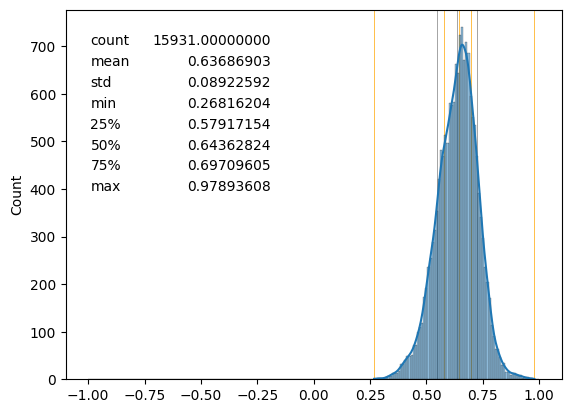

In [3]:
# Create a chimei category list.
chimei_categories_list = set_chimei_categories_list()

# Create a dictionary of the paths of the input files by chimei category.
filepaths_input_dict = set_filepaths_input_dict(chimei_categories_list)

# Create a dictionary of chimei lists by chimei category.
chimeis_lists_dict = set_chimeis_lists_dict(filepaths_input_dict)

# Set the selected model.
model = set_model(model_name_str)

# Embed chimei lists via the model.
embeddings_dicts_dict = embed_chimei(model, chimeis_lists_dict)

# Create a dictionary of the paths of the files to write embeddings to by chimei category.
# filepaths_output_embedding_dict = set_filepaths_output_dict(chimei_categories_list=chimei_categories_list, \
#                                                             directory='./embeddings/', \
#                                                             prefix='embeddings_', \
#                                                             ext='.json')

# Write embeddings to the files.
# json_dump_embeddings(embeddings_dicts_dict, filepaths_output_embedding_dict)

# Create a dictionary of the dataframes whose values are the cosine similarities of the chimei pairs by chimei category.
cossim_matrix_dfs_dict = create_cossim_matrix_dfs_dict(embeddings_dicts_dict)

# Create a dictionary of the paths of the files to write cosine similarity dataframes to by chimei category.
# filepaths_output_cossim_matrix_dict = set_filepaths_output_dict(chimei_categories_list=chimei_categories_list, \
#                                                                 directory='./cossim_0_matrix/', \
#                                                                 prefix='cossim_matrix_', \
#                                                                 ext='.csv')

# Write cosine similarity dataframes to files.
# to_csv_cossim_dfs(cossim_matrix_dfs_dict, filepaths_output_cossim_matrix_dict)

# Create a dictionary of the dataframes created with cossim matrices melted by chimei category.
cossim_melted_dfs_dict = melt_cossim_dfs_dict(cossim_matrix_dfs_dict)

# Create a dictionary of the paths of the files to write the melted cossim matrices to by chimei category.
# filepaths_output_cossim_melted_dict = set_filepaths_output_dict(chimei_categories_list=chimei_categories_list, \
#                                                                 directory='./cossim_1_melted/', \
#                                                                 prefix='cossim_melted_', \
#                                                                 ext='.csv')

# Write melted cossim matrices to files.
# to_csv_cossim_dfs(cossim_melted_dfs_dict, filepaths_output_cossim_melted_dict)

# Create a dictionary of the paths of the files to save the histgrams of the melted cossim matrices as by chimei category.
filepaths_output_cossim_mltd_hist_dict = set_filepaths_output_dict(
    chimei_categories_list=chimei_categories_list,
    directory='./cossim_1_melted_1_hist/',
    prefix='cossim_melted_hist2_',
    ext='.png'
)
# Plot and save histgrams of melted cossim matrices as files by chimei category.
plot_and_save_cossim_hists(cossim_melted_dfs_dict, filepaths_output_cossim_mltd_hist_dict)

# Create a dictionary containing statistics dataframes of melted cossim matrices by chimei category.
# cossim_melted_stats_dfs_dict = create_cossims_stats_dfs_dict(cossim_melted_dfs_dict)

# Create a dictionary of the paths of the files to write the statistics of melted cossim matrices to by chimei category.
# filepaths_output_cossim_mltd_stats_dict = set_filepaths_output_dict(chimei_categories_list=chimei_categories_list, \
#                                                                     directory='./cossim_1_melted_2_stats/', \
#                                                                     prefix='cossim_melted_stats_', \
#                                                                     ext='.csv')

# Write statistics of melted cossim matrices to files.
# to_csv_cossim_dfs(cossim_melted_stats_dfs_dict, filepaths_output_cossim_mltd_stats_dict)

